Creates Figure S3

In [1]:
#import packages needed for script
import skill_metrics as sm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from natsort import natsorted 
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec


ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat



In [3]:
#set up the data directory and load in lon + lat + time dimensions
#outputdir='/glade/scratch/asphilli/OBrien_etal/' 
outputdir='/glade/work/nmaher/SEOF_output/'
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'

#load obs

model='OBS'
#option for single files - put one file path here to get lon/lat/time
ds_fx = xr.open_dataset(outputdir+'20CRv3.z500.eof.npac.djf.1958-2015.nc_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat
time = ds_fx.time

eof_T='_PNA'
with np.load(outputdir+model+eof_T+'_SEOF.npz') as npz:
    eof = np.ma.MaskedArray(**npz)
    

eof_T='_NAT'
with np.load(outputdir+model+eof_T+'_SEOF.npz') as npz:
    eofNat = np.ma.MaskedArray(**npz)
  

model='OBS_ERSST'

eof_T='_TPAC_SST'
with np.load(outputdir+model+eof_T+'_SEOF.npz') as npz:
    eofTpac = np.ma.MaskedArray(**npz)
    
eof2=eof
eof2[1,:,:]=eof2[1,:,:]*-1
eof2[2,:,:]=eof2[2,:,:]
eofNat2=eofNat 
eofTpac2=eofTpac 
eofTpac2[1,:,:]=eofTpac2[1,:,:]*-1


In [4]:
models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']
models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]

outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'

eof_T1='_PNA'
eof_T2='_NAT'
eof_T3='_TPAC_SST'



In [5]:
lon[0:140]


<xarray.DataArray 'lon' (lon: 140)>
array([  1.25,   3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
        23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,  43.75,
        46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,  63.75,  66.25,
        68.75,  71.25,  73.75,  76.25,  78.75,  81.25,  83.75,  86.25,  88.75,
        91.25,  93.75,  96.25,  98.75, 101.25, 103.75, 106.25, 108.75, 111.25,
       113.75, 116.25, 118.75, 121.25, 123.75, 126.25, 128.75, 131.25, 133.75,
       136.25, 138.75, 141.25, 143.75, 146.25, 148.75, 151.25, 153.75, 156.25,
       158.75, 161.25, 163.75, 166.25, 168.75, 171.25, 173.75, 176.25, 178.75,
       181.25, 183.75, 186.25, 188.75, 191.25, 193.75, 196.25, 198.75, 201.25,
       203.75, 206.25, 208.75, 211.25, 213.75, 216.25, 218.75, 221.25, 223.75,
       226.25, 228.75, 231.25, 233.75, 236.25, 238.75, 241.25, 243.75, 246.25,
       248.75, 251.25, 253.75, 256.25, 258.75, 261.25, 263.75, 266.25, 268.75,
       271.25, 273.75, 276.25, 278.75, 281.25, 283.75, 286.25, 288.75, 291.25,
       293.75, 296.25, 298.75, 301.25, 303.75, 306.25, 308.75, 311.25, 313.75,
       316.25, 318.75, 321.25, 323.75, 326.25, 328.75, 331.25, 333.75, 336.25,
       338.75, 341.25, 343.75, 346.25, 348.75])
Coordinates:
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 341.2 343.8 346.2 348.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [6]:
model=models[0]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])



#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac

#pna_seof2=data_z500_npac
#for i in range(len(data_z500_npac[:,0,0,0])):
#    for j in range(144):
#        pna_seof2[i,2,:,j]=data_z500_npac[i,2,:,j]*np.cos(lat)

for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,48:60,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,48:60,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]

cesm2_z500_npac2=pna_seof_phcorr     
cesm2_z500_nat2=nat_seof_phcorr
cesm2_z500_tpac2=tpac_seof_phcorr
cesm2_z500_tpac2[:,1,:,:]=cesm2_z500_tpac2[:,1,:,:]*-1

In [7]:
     
model=models[1]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])



#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb
# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]



cesm1_z500_npac2=pna_seof_phcorr     
cesm1_z500_nat2=nat_seof_phcorr*-1
cesm1_z500_tpac2=tpac_seof_phcorr
cesm1_z500_npac2[:,1,:,:]=cesm1_z500_npac2[:,1,:,:]*-1
cesm1_z500_tpac2[:,0,:,:]=cesm1_z500_tpac2[:,0,:,:]*-1

In [8]:
     
model=models[2]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb
# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


AC_z500_npac2=pna_seof_phcorr     
AC_z500_nat2=nat_seof_phcorr
AC_z500_tpac2=tpac_seof_phcorr
AC_z500_npac2[:,0,:,:]=AC_z500_npac2[:,0,:,:]*-1
AC_z500_tpac2[:,0,:,:]=AC_z500_tpac2[:,0,:,:]*-1

In [9]:
     
model=models[3]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


Can_z500_npac2=pna_seof_phcorr     
Can_z500_nat2=nat_seof_phcorr*-1
Can_z500_tpac2=tpac_seof_phcorr
Can_z500_npac2[:,0,:,:]=Can_z500_npac2[:,0,:,:]*-1
Can_z500_npac2[:,2,:,:]=Can_z500_npac2[:,2,:,:]*-1


In [10]:
model=models[4]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb
# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


SP_z500_npac2=pna_seof_phcorr     
SP_z500_nat2=nat_seof_phcorr*-1
SP_z500_tpac2=tpac_seof_phcorr
SP_z500_npac2[:,1,:,:]=SP_z500_npac2[:,1,:,:]*-1
SP_z500_tpac2[:,0,:,:]=SP_z500_tpac2[:,0,:,:]*-1

In [11]:
model=models[5]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])

#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb
# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]


IP_z500_npac2=pna_seof_phcorr     
IP_z500_nat2=nat_seof_phcorr*-1
IP_z500_tpac2=tpac_seof_phcorr
IP_z500_npac2[:,0,:,:]=IP_z500_npac2[:,0,:,:]*-1
IP_z500_tpac2[:,0,:,:]=IP_z500_tpac2[:,0,:,:]*-1
IP_z500_npac2[:,1,:,:]=IP_z500_npac2[:,1,:,:]*-1
IP_z500_npac2[:,2,:,:]=IP_z500_npac2[:,2,:,:]*-1
IP_z500_tpac2[:,1,:,:]=IP_z500_tpac2[:,1,:,:]*-1


In [12]:
model=models[6]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb
# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]



M6_z500_npac2=pna_seof_phcorr     
M6_z500_nat2=nat_seof_phcorr
M6_z500_tpac2=tpac_seof_phcorr
M6_z500_npac2[:,1,:,:]=M6_z500_npac2[:,1,:,:]*-1
M6_z500_tpac2[:,0,:,:]=M6_z500_tpac2[:,0,:,:]*-1

In [13]:
model=models[7]

with np.load(outputdir_figD+model+eof_T1+'_SEOF_time.npz') as npz:
    data_z500_npac = np.ma.MaskedArray(**npz)
   
with np.load(outputdir_figD+model+eof_T2+'_SEOF_time.npz') as npz:
    data_z500_nat = np.ma.MaskedArray(**npz)    

with np.load(outputdir_figD+model+eof_T3+'_SEOF_time.npz') as npz:
    data_z500_tpac = np.ma.MaskedArray(**npz)    
    
ntt=len(data_z500_nat[:,0,0,0])


#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
pna_seof=data_z500_npac
for i in range(ntt):

    #eof0a = eof2[0,...].flatten() - eof2[0,...].mean()
    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()    
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    #eof0b = eof2[1,...].flatten() - eof2[1,...].mean()
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    #eof0c = eof2[2,...].flatten() - eof2[2,...].mean()
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()    
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr_array[0,:]<0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr_array[1,:]<0)[0]
pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]

# flip seofs/spcs 2
ineg = np.nonzero(pattCorr_array[2,:]<0)[0]
pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]


#make sure the EOFs are all in the right direction 
pattCorr2_array = np.ma.masked_equal(np.zeros([1,ntt]),0)
nat_seof=data_z500_nat
for i in range(ntt):

    #eof0a = eofNat2[0,...].flatten() - eofNat2[0,...].mean()
    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()    
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr2_array[0,i] = num


# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

# flip seofs/spcs 0
ineg = np.nonzero(pattCorr2_array[0,:]<0)[0]
nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]


#make sure the EOFs are all in the right direction 
pattCorr3_array = np.ma.masked_equal(np.zeros([3,ntt]),0)
tpac_seof=data_z500_tpac
for i in range(ntt):

    #eof0a = eofTpac2[0,...].flatten() - eofTpac2[0,...].mean()
    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr3_array[0,i] = num
    #eof0b = eofTpac2[1,...].flatten() - eofTpac2[1,...].mean()
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr3_array[1,i] = numb
# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

# flip seofs/spcs 0

ineg = np.nonzero(pattCorr3_array[0,:]<0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]

# flip seofs/spcs 1
ineg = np.nonzero(pattCorr3_array[1,:]<0)[0]
tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]



MP_z500_npac2=pna_seof_phcorr     
MP_z500_nat2=nat_seof_phcorr
MP_z500_tpac2=tpac_seof_phcorr
MP_z500_npac2[:,0,:,:]=MP_z500_npac2[:,0,:,:]*-1
MP_z500_npac2[:,2,:,:]=MP_z500_npac2[:,2,:,:]*-1
MP_z500_tpac2[:,1,:,:]=MP_z500_tpac2[:,1,:,:]*-1


In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

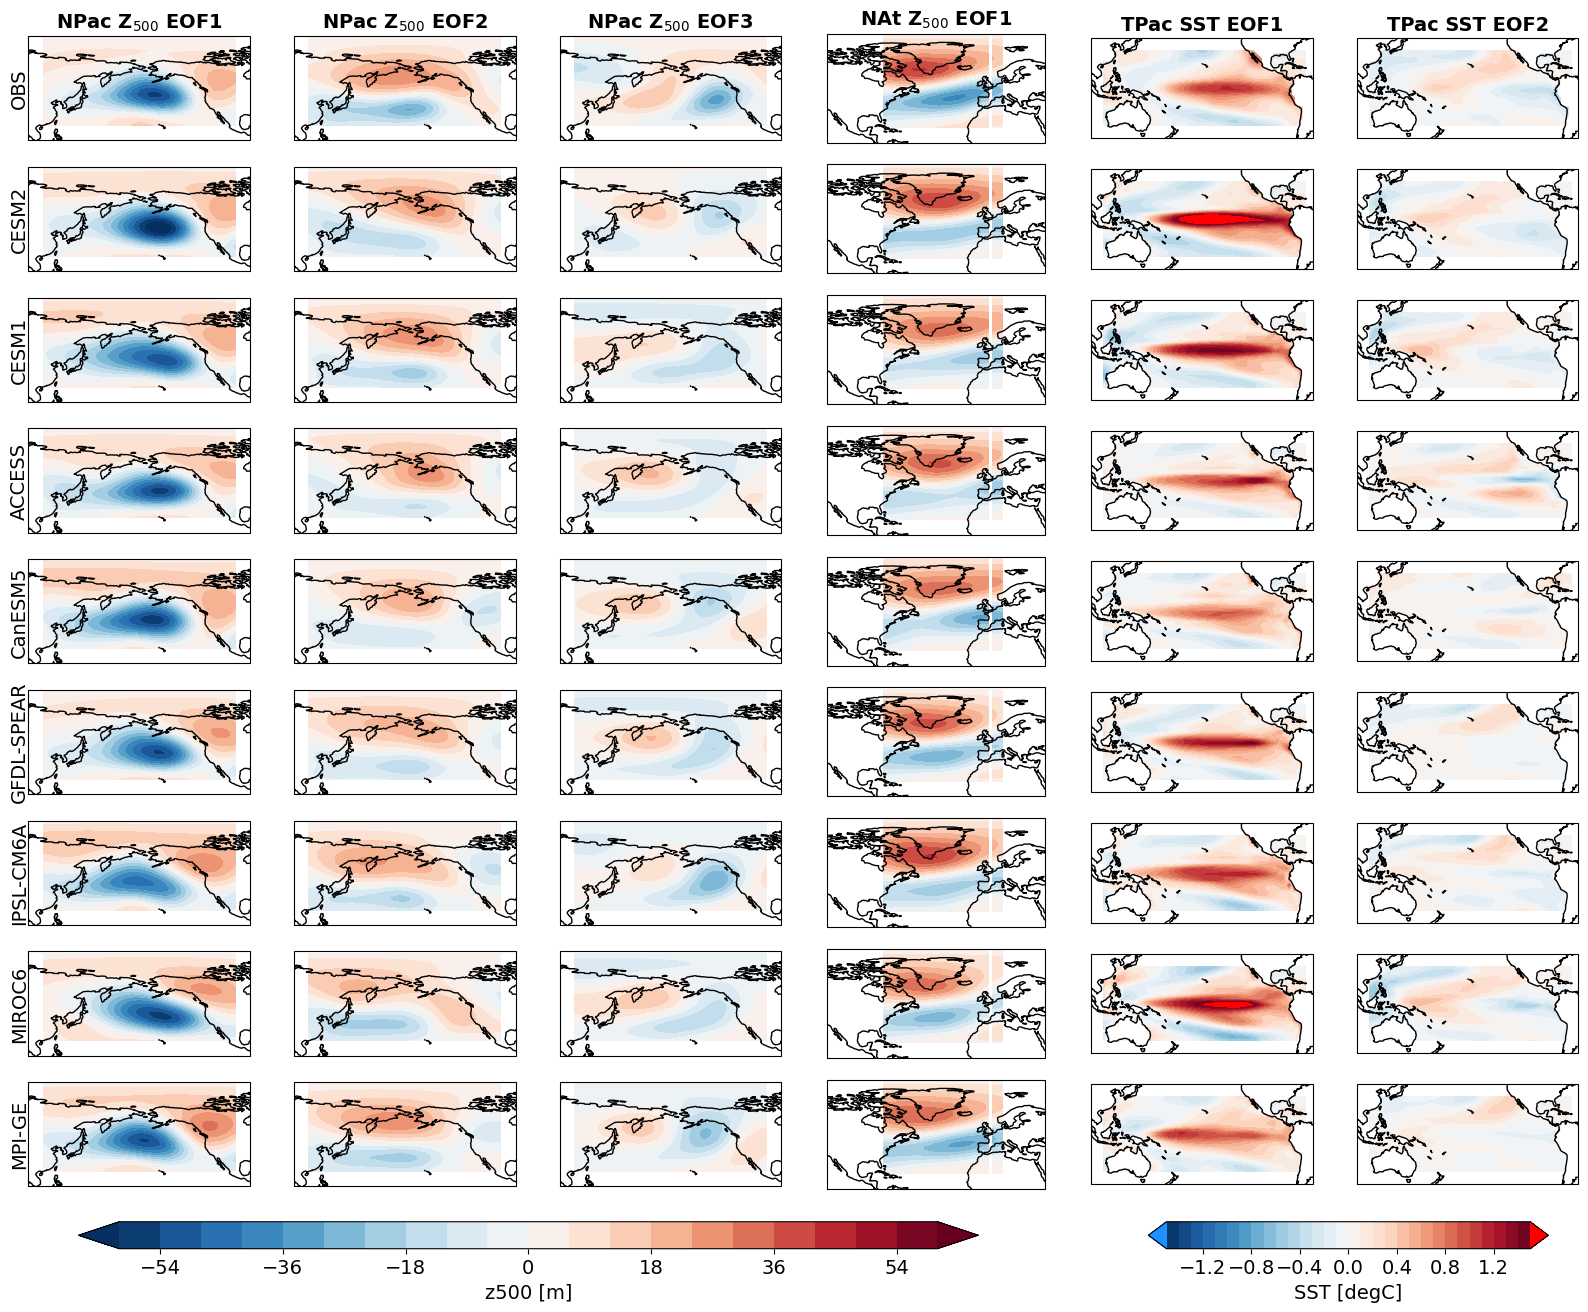

In [25]:
label = ['obs']+models

#plot data

fig,axs = PP.subplots(9,6,figsize=(20,15), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})

slevels = np.linspace(0,10)
#set up colours and levels
levels = np.linspace(-60,60,21)
cmap = copy.deepcopy(mpl.cm.RdBu_r)
cmap2='OrRd'

#eof1
cplt = axs[0,0].contourf(lon,lat,np.squeeze(eof2[0,:,:]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[0,0].coastlines()
axs[0,0].set_ylim(10,90)
axs[0,0].set_xlim(-170,0)

cplt = axs[1,0].contourf(lon,lat,np.mean(cesm2_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[1,0].coastlines()
axs[1,0].set_ylim(10,90)
axs[1,0].set_xlim(-170,0)

cplt = axs[2,0].contourf(lon,lat,np.mean(cesm1_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[2,0].coastlines()
axs[2,0].set_ylim(10,90)
axs[2,0].set_xlim(-170,0)

cplt = axs[3,0].contourf(lon,lat,np.mean(AC_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[3,0].coastlines()
axs[3,0].set_ylim(10,90)
axs[3,0].set_xlim(-170,0)

cplt = axs[4,0].contourf(lon,lat,np.mean(Can_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[4,0].coastlines()
axs[4,0].set_ylim(10,90)
axs[4,0].set_xlim(-170,0)

cplt = axs[5,0].contourf(lon,lat,np.mean(SP_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[5,0].coastlines()
axs[5,0].set_ylim(10,90)
axs[5,0].set_xlim(-170,0)

cplt = axs[6,0].contourf(lon,lat,np.mean(IP_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[6,0].coastlines()
axs[6,0].set_ylim(10,90)
axs[6,0].set_xlim(-170,0)

cplt = axs[7,0].contourf(lon,lat,np.mean(M6_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[7,0].coastlines()
axs[7,0].set_ylim(10,90)
axs[7,0].set_xlim(-170,0)

cplt = axs[8,0].contourf(lon,lat,np.mean(MP_z500_npac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[8,0].coastlines()
axs[8,0].set_ylim(10,90)
axs[8,0].set_xlim(-170,0)

#eof2

cplt = axs[0,1].contourf(lon,lat,np.squeeze(eof2[1,:,:]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[0,1].coastlines()
axs[0,1].set_ylim(10,90)
axs[0,1].set_xlim(-170,0)

cplt = axs[1,1].contourf(lon,lat,np.mean(cesm2_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[1,1].coastlines()
axs[1,1].set_ylim(10,90)
axs[1,1].set_xlim(-170,0)

cplt = axs[2,1].contourf(lon,lat,np.mean(cesm1_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[2,1].coastlines()
axs[2,1].set_ylim(10,90)
axs[2,1].set_xlim(-170,0)

cplt = axs[3,1].contourf(lon,lat,np.mean(AC_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[3,1].coastlines()
axs[3,1].set_ylim(10,90)
axs[3,1].set_xlim(-170,0)

cplt = axs[4,1].contourf(lon,lat,np.mean(Can_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[4,1].coastlines()
axs[4,1].set_ylim(10,90)
axs[4,1].set_xlim(-170,0)

cplt = axs[5,1].contourf(lon,lat,np.mean(SP_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[5,1].coastlines()
axs[5,1].set_ylim(10,90)
axs[5,1].set_xlim(-170,0)

cplt = axs[6,1].contourf(lon,lat,np.mean(IP_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[6,1].coastlines()
axs[6,1].set_ylim(10,90)
axs[6,1].set_xlim(-170,0)

cplt = axs[7,1].contourf(lon,lat,np.mean(M6_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[7,1].coastlines()
axs[7,1].set_ylim(10,90)
axs[7,1].set_xlim(-170,0)

cplt = axs[8,1].contourf(lon,lat,np.mean(MP_z500_npac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[8,1].coastlines()
axs[8,1].set_ylim(10,90)
axs[8,1].set_xlim(-170,0)

#eof3
cplt = axs[0,2].contourf(lon,lat,np.squeeze(eof2[2,:,:]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[0,2].coastlines()
axs[0,2].set_ylim(10,90)
axs[0,2].set_xlim(-170,0)

cplt = axs[1,2].contourf(lon,lat,np.mean(cesm2_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[1,2].coastlines()
axs[1,2].set_ylim(10,90)
axs[1,2].set_xlim(-170,0)

cplt = axs[2,2].contourf(lon,lat,np.mean(cesm1_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[2,2].coastlines()
axs[2,2].set_ylim(10,90)
axs[2,2].set_xlim(-170,0)

cplt = axs[3,2].contourf(lon,lat,np.mean(AC_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[3,2].coastlines()
axs[3,2].set_ylim(10,90)
axs[3,2].set_xlim(-170,0)

cplt = axs[4,2].contourf(lon,lat,np.mean(Can_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[4,2].coastlines()
axs[4,2].set_ylim(10,90)
axs[4,2].set_xlim(-170,0)

cplt = axs[5,2].contourf(lon,lat,np.mean(SP_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[5,2].coastlines()
axs[5,2].set_ylim(10,90)
axs[5,2].set_xlim(-170,0)

cplt = axs[6,2].contourf(lon,lat,np.mean(IP_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[6,2].coastlines()
axs[6,2].set_ylim(10,90)
axs[6,2].set_xlim(-170,0)

cplt = axs[7,2].contourf(lon,lat,np.mean(M6_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[7,2].coastlines()
axs[7,2].set_ylim(10,90)
axs[7,2].set_xlim(-170,0)

cplt = axs[8,2].contourf(lon,lat,np.mean(MP_z500_npac2[:,2,:,:],axis=0)*-1, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[8,2].coastlines()
axs[8,2].set_ylim(10,90)
axs[8,2].set_xlim(-170,0)

PP.text(-0.04,0.5,'OBS', rotation=90, fontsize=14, ha='center', va='center', transform=axs[0,0].transAxes)
PP.text(-0.04,0.5,models_title[0], rotation=90, fontsize=14, ha='center', va='center', transform=axs[1,0].transAxes)
PP.text(-0.04,0.5,models_title[1], rotation=90, fontsize=14, ha='center', va='center', transform=axs[2,0].transAxes)
PP.text(-0.04,0.5,models_title[2], rotation=90, fontsize=14, ha='center', va='center', transform=axs[3,0].transAxes)
PP.text(-0.04,0.5,models_title[3], rotation=90, fontsize=14, ha='center', va='center', transform=axs[4,0].transAxes)
PP.text(-0.04,0.5,models_title[4], rotation=90, fontsize=14, ha='center', va='center', transform=axs[5,0].transAxes)
PP.text(-0.04,0.5,models_title[5], rotation=90, fontsize=14, ha='center', va='center', transform=axs[6,0].transAxes)
PP.text(-0.04,0.5,models_title[6], rotation=90, fontsize=14, ha='center', va='center', transform=axs[7,0].transAxes)
PP.text(-0.04,0.5,models_title[7], rotation=90, fontsize=14, ha='center', va='center', transform=axs[8,0].transAxes)

axs[0,0].set_title('NPac Z$_{500}$ EOF1', fontsize=14, weight='bold')
axs[0,1].set_title('NPac Z$_{500}$ EOF2', fontsize=14, weight='bold')
axs[0,2].set_title('NPac Z$_{500}$ EOF3', fontsize=14, weight='bold')

cticks = np.linspace(0,10,11)
cbar_ax = fig.add_axes([0.15, 0.07, 0.45, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal')#, ticks=cticks)
cbar.set_label('z500 [m]',fontsize=14)
cbar.ax.tick_params(labelsize=14)

##### break


label = ['obs']+models

#plot data


slevels = np.linspace(0,10)
#set up colours and levels
levels = np.linspace(-60,60,21)
cmap = copy.deepcopy(mpl.cm.RdBu_r)
cmap2='OrRd'

#eof1
cplt = axs[0,0+3].contourf(lon,lat,np.squeeze(eofNat2[0,:,:]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[0,0+3].coastlines()
axs[0,0+3].set_ylim(10,90)
axs[0,0+3].set_xlim(-30,130)

cplt = axs[1,0+3].contourf(lon,lat,np.mean(cesm2_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[1,0+3].coastlines()
axs[1,0+3].set_ylim(10,90)
axs[1,0+3].set_xlim(-30,130)

cplt = axs[2,0+3].contourf(lon,lat,np.mean(cesm1_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[2,0+3].coastlines()
axs[2,0+3].set_ylim(10,90)
axs[2,0+3].set_xlim(-30,130)

cplt = axs[3,0+3].contourf(lon,lat,np.mean(AC_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[3,0+3].coastlines()
axs[3,0+3].set_ylim(10,90)
axs[3,0+3].set_xlim(-30,130)

cplt = axs[4,0+3].contourf(lon,lat,np.mean(Can_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[4,0+3].coastlines()
axs[4,0+3].set_ylim(10,90)
axs[4,0+3].set_xlim(-30,130)

cplt = axs[5,0+3].contourf(lon,lat,np.mean(SP_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[5,0+3].coastlines()
axs[5,0+3].set_ylim(10,90)
axs[5,0+3].set_xlim(-30,130)

cplt = axs[6,0+3].contourf(lon,lat,np.mean(IP_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[6,0+3].coastlines()
axs[6,0+3].set_ylim(10,90)
axs[6,0+3].set_xlim(-30,130)

cplt = axs[7,0+3].contourf(lon,lat,np.mean(M6_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[7,0+3].coastlines()
axs[7,0+3].set_ylim(10,90)
axs[7,0+3].set_xlim(-30,130)

cplt = axs[8,0+3].contourf(lon,lat,np.mean(MP_z500_nat2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[8,0+3].coastlines()
axs[8,0+3].set_ylim(10,90)
axs[8,0+3].set_xlim(-30,130)


#cticks = np.linspace(0,10,11)
#cbar_ax = fig.add_axes([0.52, 0.07, 0.12, 0.018])
#cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal')#, ticks=cticks)
#cbar.set_label('z500 [m]')

#eof2
slevels = np.linspace(0,1)
levels = np.arange(-1.5,1.6,0.1)
cmap = copy.deepcopy(mpl.cm.RdBu_r)
cmap.set_under('dodgerblue')  # need to confirm this color
cmap.set_over('red')  # need to confirm this color


cplt = axs[0,1+3].contourf(lon,lat,np.squeeze(eofTpac2[0,:,:]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[0,1+3].coastlines()
axs[0,1+3].set_ylim(-45,45)
axs[0,1+3].set_xlim(-170,30)
4
cplt = axs[1,1+3].contourf(lon,lat,np.mean(cesm2_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[1,1+3].coastlines()
axs[1,1+3].set_ylim(-45,45)
axs[1,1+3].set_xlim(-170,30)

cplt = axs[2,1+3].contourf(lon,lat,np.mean(cesm1_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[2,1+3].coastlines()
axs[2,1+3].set_ylim(-45,45)
axs[2,1+3].set_xlim(-170,30)

cplt = axs[3,1+3].contourf(lon,lat,np.mean(AC_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[3,1+3].coastlines()
axs[3,1+3].set_ylim(-45,45)
axs[3,1+3].set_xlim(-170,30)

cplt = axs[4,1+3].contourf(lon,lat,np.mean(Can_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[4,1+3].coastlines()
axs[4,1+3].set_ylim(-45,45)
axs[4,1+3].set_xlim(-170,30)

cplt = axs[5,1+3].contourf(lon,lat,np.mean(SP_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[5,1+3].coastlines()
axs[5,1+3].set_ylim(-45,45)
axs[5,1+3].set_xlim(-170,30)

cplt = axs[6,1+3].contourf(lon,lat,np.mean(IP_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[6,1+3].coastlines()
axs[6,1+3].set_ylim(-45,45)
axs[6,1+3].set_xlim(-170,30)

cplt = axs[7,1+3].contourf(lon,lat,np.mean(M6_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[7,1+3].coastlines()
axs[7,1+3].set_ylim(-45,45)
axs[7,1+3].set_xlim(-170,30)

cplt = axs[8,1+3].contourf(lon,lat,np.mean(MP_z500_tpac2[:,0,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[8,1+3].coastlines()
axs[8,1+3].set_ylim(-45,45)
axs[8,1+3].set_xlim(-170,30)




#eof3
cplt = axs[0,2+3].contourf(lon,lat,np.squeeze(eofTpac2[1,:,:]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[0,2+3].coastlines()
axs[0,2+3].set_ylim(-45,45)
axs[0,2+3].set_xlim(-170,30)

cplt = axs[1,2+3].contourf(lon,lat,np.mean(cesm2_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[1,2+3].coastlines()
axs[1,2+3].set_ylim(-45,45)
axs[1,2+3].set_xlim(-170,30)

cplt = axs[2,2+3].contourf(lon,lat,np.mean(cesm1_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[2,2+3].coastlines()
axs[2,2+3].set_ylim(-45,45)
axs[2,2+3].set_xlim(-170,30)

cplt = axs[3,2+3].contourf(lon,lat,np.mean(AC_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[3,2+3].coastlines()
axs[3,2+3].set_ylim(-45,45)
axs[3,2+3].set_xlim(-170,30)

cplt = axs[4,2+3].contourf(lon,lat,np.mean(Can_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[4,2+3].coastlines()
axs[4,2+3].set_ylim(-45,45)
axs[4,2+3].set_xlim(-170,30)

cplt = axs[5,2+3].contourf(lon,lat,np.mean(SP_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[5,2+3].coastlines()
axs[5,2+3].set_ylim(-45,45)
axs[5,2+3].set_xlim(-170,30)

cplt = axs[6,2+3].contourf(lon,lat,np.mean(IP_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[6,2+3].coastlines()
axs[6,2+3].set_ylim(-45,45)
axs[6,2+3].set_xlim(-170,30)

cplt = axs[7,2+3].contourf(lon,lat,np.mean(M6_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[7,2+3].coastlines()
axs[7,2+3].set_ylim(-45,45)
axs[7,2+3].set_xlim(-170,30)

cplt = axs[8,2+3].contourf(lon,lat,np.mean(MP_z500_tpac2[:,1,:,:],axis=0), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
axs[8,2+3].coastlines()
axs[8,2+3].set_ylim(-45,45)
axs[8,2+3].set_xlim(-170,30)



axs[0,0+3].set_title('NAt Z$_{500}$ EOF1', fontsize=14, weight='bold')
axs[0,1+3].set_title('TPac SST EOF1', fontsize=14, weight='bold')
axs[0,2+3].set_title('TPac SST EOF2', fontsize=14, weight='bold')

cticks = np.linspace(0,10,11)
cbar_ax = fig.add_axes([0.685, 0.07, 0.2, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal')#, ticks=cticks)
cbar.set_label('SST [degC]',fontsize=14)
cbar.ax.tick_params(labelsize=14)

outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
plt.savefig(outputdir2+'Figure_S3.png', dpi=300, bbox_inches='tight')

In [16]:
lon

lat_range=[-35,35]
lon_range=[110,295]



In [17]:
lon[60:105]
#lat[24:44]


<xarray.DataArray 'lon' (lon: 45)>
array([151.25, 153.75, 156.25, 158.75, 161.25, 163.75, 166.25, 168.75, 171.25,
       173.75, 176.25, 178.75, 181.25, 183.75, 186.25, 188.75, 191.25, 193.75,
       196.25, 198.75, 201.25, 203.75, 206.25, 208.75, 211.25, 213.75, 216.25,
       218.75, 221.25, 223.75, 226.25, 228.75, 231.25, 233.75, 236.25, 238.75,
       241.25, 243.75, 246.25, 248.75, 251.25, 253.75, 256.25, 258.75, 261.25])
Coordinates:
  * lon      (lon) float64 151.2 153.8 156.2 158.8 ... 253.8 256.2 258.8 261.2
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

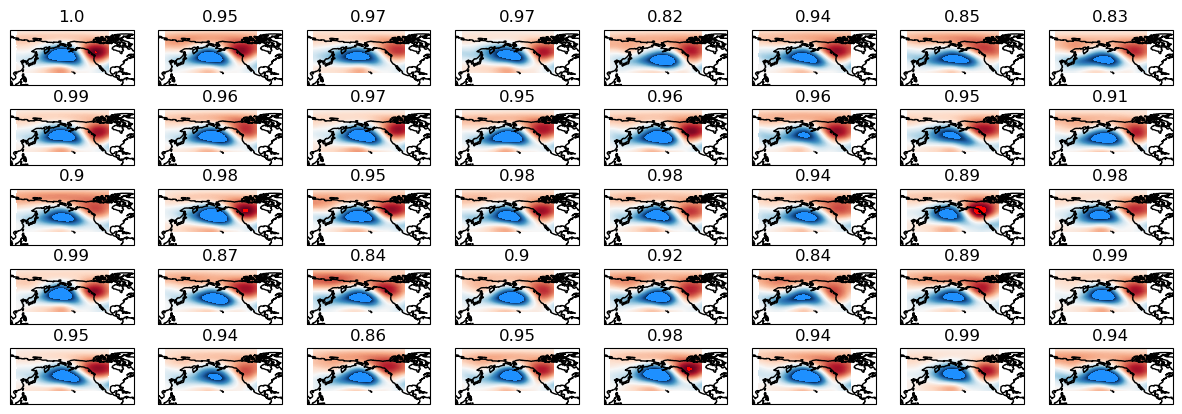

In [18]:
#22:50, 44:118

outputdir2='/glade/work/nmaher/SEOF_output/figs_final/EOF_test/'


model=MP_z500_npac2
model2='MP_z500_npac2'

x=len(model[:,0,0,0])

e=0

ccoef5= np.zeros(x+1)
ccoef5[0]=  1
for ii in range(x):
    x=model[ii,e,:,:].flatten()
    y=model[0,e,:,:].flatten()
    
    #y=eofTpac2[e,22:50,61:118].flatten()
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = round(ccoefA[0,1],2) 


fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-40,40,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):#8
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,model[tt,e,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(0,90)
        axs[ii,jj].set_xlim(-170,30)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))

plt.savefig(outputdir2+model2+'_'+str(e)+'_testEOF', dpi=300, bbox_inches='tight')

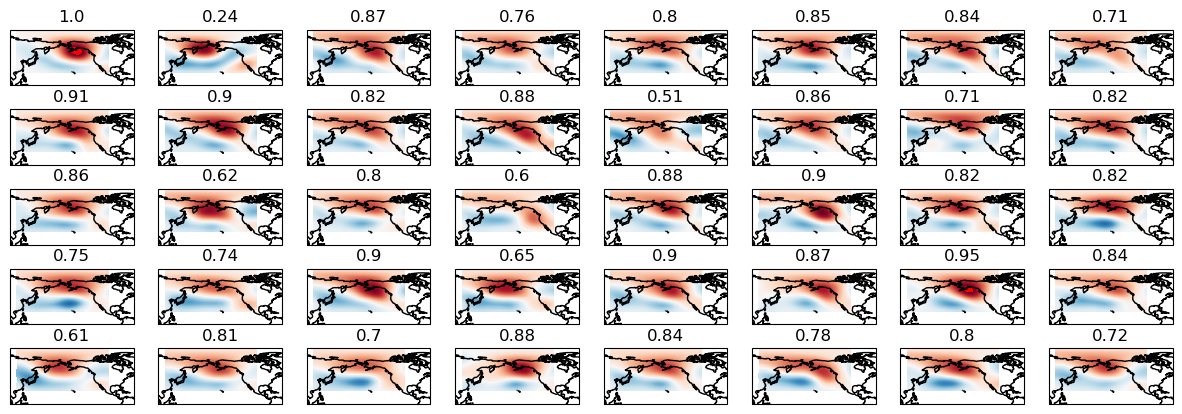

In [19]:
#22:50, 44:118

model=cesm2_z500_npac2
model2='cesm2_z500_npac2'
e=1

x=len(model[:,0,0,0])


ccoef5= np.zeros(x+1)
ccoef5[0]=  1
for ii in range(x):
    x=model[ii,e,:,:].flatten()
    y=model[0,e,:,:].flatten()
    
    #y=eofTpac2[e,22:50,61:118].flatten()
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = round(ccoefA[0,1],2) 

fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-40,40,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,model[tt,e,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(0,90)
        axs[ii,jj].set_xlim(-170,30)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))

#plt.savefig(outputdir2+model2+'_'+str(e)+'_testEOF', dpi=300, bbox_inches='tight')

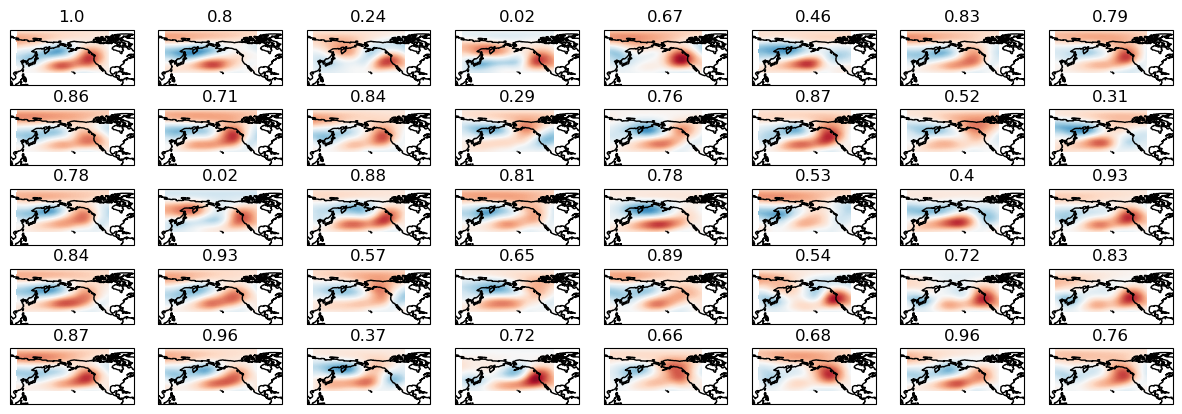

In [20]:
#22:50, 44:118

model=cesm1_z500_npac2
model2='cesm1_z500_npac2'
e=2

x=len(model[:,0,0,0])


ccoef5= np.zeros(x+1)
ccoef5[0]=  1
for ii in range(x):
    x=model[ii,e,:,:].flatten()
    y=model[0,e,:,:].flatten()
    
    #y=eofTpac2[e,22:50,61:118].flatten()
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = round(ccoefA[0,1],2) 

fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-40,40,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,model[tt,e,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(0,90)
        axs[ii,jj].set_xlim(-170,30)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))
        #axs[ii,jj].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

plt.savefig(outputdir2+model2+'_'+str(e)+'_testEOF', dpi=300, bbox_inches='tight')

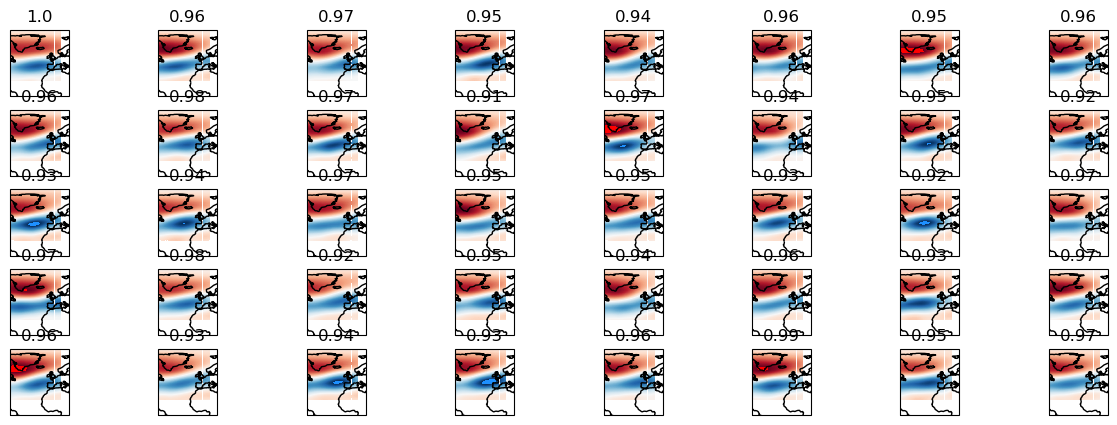

In [21]:
#22:50, 44:118

model=MP_z500_nat2
model2='MP_z500_nat2'

x=len(model[:,0,0,0])


e=0
ccoef5= np.zeros(x+1)
ccoef5[0]=  1
for ii in range(x):
    x=model[ii,e,:,:].flatten()
    y=model[0,e,:,:].flatten()
    
    #y=eofTpac2[e,22:50,61:118].flatten()
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = round(ccoefA[0,1],2) 

fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-40,40,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,model[tt,e,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(0,90)
        axs[ii,jj].set_xlim(30,110)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))

plt.savefig(outputdir2+model2+'_'+str(e)+'_testEOF', dpi=300, bbox_inches='tight')

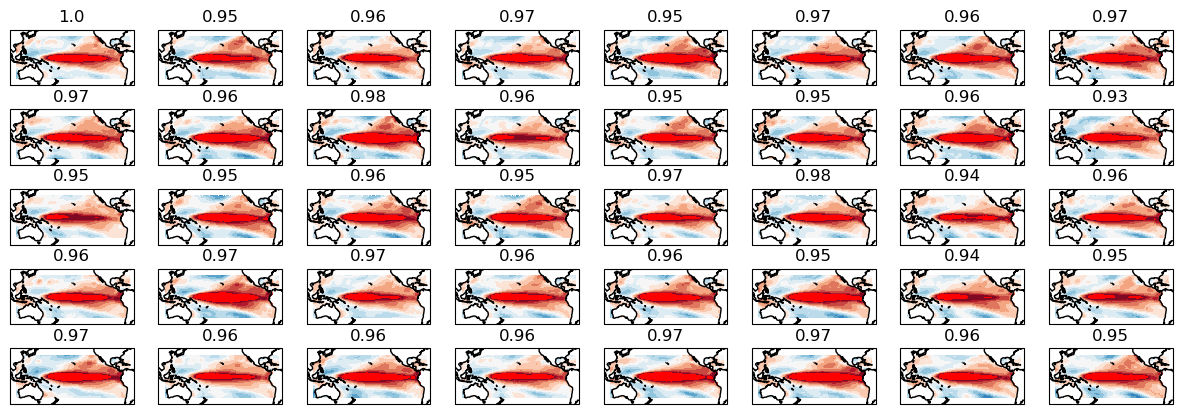

In [22]:
#22:50, 44:118

model=MP_z500_tpac2
model2='MP_z500_tpac2'

x=len(model[:,0,0,0])


e=0
ccoef5= np.zeros(x+1)
ccoef5[0]=  1
for ii in range(x):
    x=model[ii,e,:,:].flatten()
    y=model[0,e,:,:].flatten()
    
    #y=eofTpac2[e,22:50,61:118].flatten()
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = round(ccoefA[0,1],2) 

fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-0.75,0.85,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,model[tt,e,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(-45,45)
        axs[ii,jj].set_xlim(-170,30)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))

plt.savefig(outputdir2+model2+'_'+str(e)+'_testEOF', dpi=300, bbox_inches='tight')

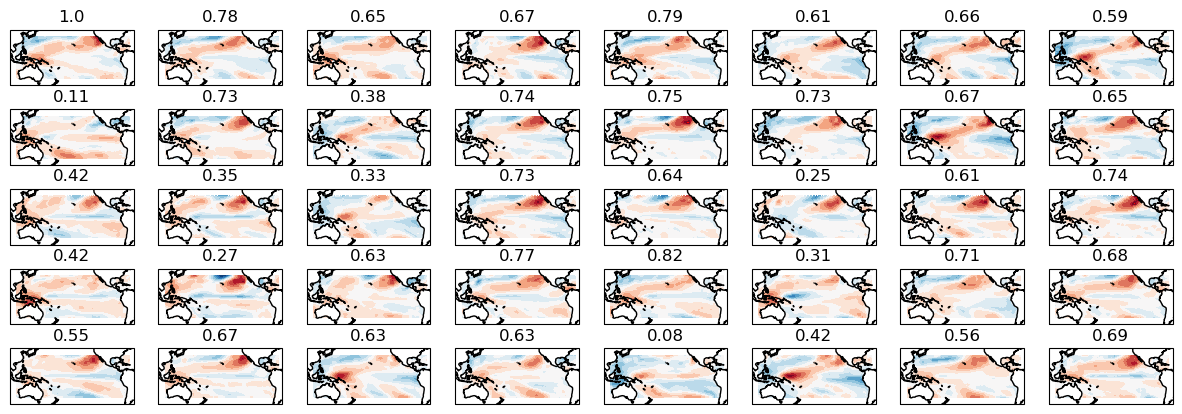

In [23]:
#22:50, 44:118

model=MP_z500_tpac2
model2='MP_z500_tpac2'

x=len(model[:,0,0,0])


e=1
ccoef5= np.zeros(x+1)
ccoef5[0]=  1
for ii in range(x):
    x=model[ii,e,:,:].flatten()
    y=model[0,e,:,:].flatten()
    
    #y=eofTpac2[e,22:50,61:118].flatten()
    x1=x[np.logical_not(np.isnan(x))]
    y1=y[np.logical_not(np.isnan(x))]
    x2=x1[np.logical_not(np.isnan(y1))]
    y2=y1[np.logical_not(np.isnan(y1))]
    ccoefA = np.corrcoef(x2,y2)
    ccoef5[ii+1] = round(ccoefA[0,1],2) 

fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-0.75,0.85,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,model[tt,e,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(-45,45)
        axs[ii,jj].set_xlim(-170,30)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))

plt.savefig(outputdir2+model2+'_'+str(e)+'_testEOF', dpi=300, bbox_inches='tight')

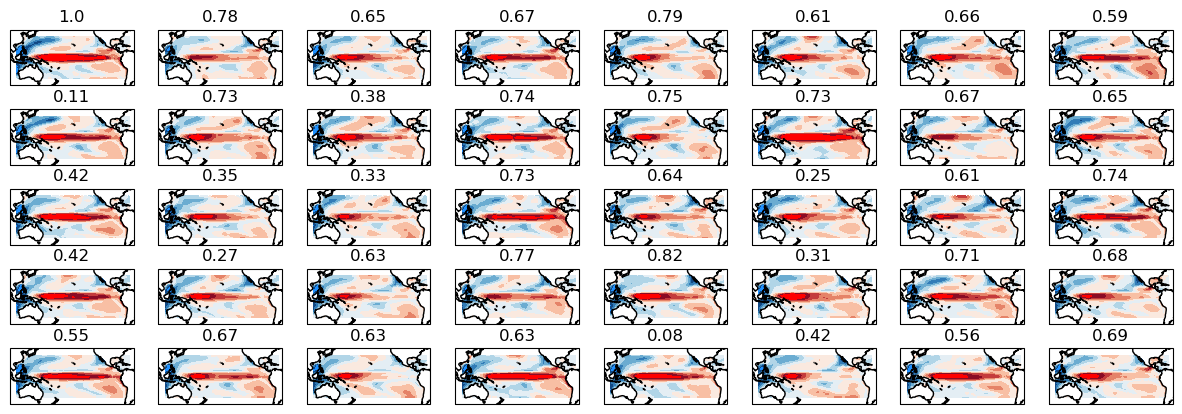

In [24]:
fig,axs = PP.subplots(5,8,figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})
levels = np.arange(-0.5,0.6,0.1)

tt=-1
for ii in range(5):
    for jj in range(8):
        tt=tt+1
        cplt = axs[ii,jj].contourf(lon,lat,cesm1_z500_tpac2[tt,0,:,:]-eofTpac2[0,:,:], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
        axs[ii,jj].coastlines()
        axs[ii,jj].set_ylim(-45,45)
        axs[ii,jj].set_xlim(-170,30)
        axs[ii,jj].set_title(str(ccoef5[tt+1]))